In [1]:
import coffea
from coffea import util
import numpy as np
import pandas as pd
import itertools
import os
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")


## analysis categories

In [2]:
# analysis categories #
# ttagcats = ["AT&Pt", "at", "pret", "0t", "1t", ">=1t", "2t", ">=0t"]
ttagcats = ["at", "pret", "2t"]
btagcats = ["0b", "1b", "2b"]
ycats = ['cen', 'fwd']

anacats = [ t+b+y for t,b,y in itertools.product( ttagcats, btagcats, ycats) ]
label_dict = {i: label for i, label in enumerate(anacats)}
label_to_int_dict = {label: i for i, label in enumerate(anacats)}
print(label_dict)
# print(label_to_int_dict)

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


In [3]:
# label_dict

## directories for saving files

In [4]:
directories = [
    '../plots/images/png/mistagRate/2016all',
    '../plots/images/png/mistagRate/2016APV',
    '../plots/images/png/mistagRate/2016',
    '../plots/images/png/mistagRate/2017',
    '../plots/images/png/mistagRate/2018',
    '../plots/images/pdf/mistagRate/2016all',
    '../plots/images/pdf/mistagRate/2016APV',
    '../plots/images/pdf/mistagRate/2016',
    '../plots/images/pdf/mistagRate/2017',
    '../plots/images/pdf/mistagRate/2018',
    '../plots/images/png/mistagRateQCD/2016all',
    '../plots/images/png/mistagRateQCD/2016APV',
    '../plots/images/png/mistagRateQCD/2016',
    '../plots/images/png/mistagRateQCD/2017',
    '../plots/images/png/mistagRateQCD/2018',
    '../plots/images/pdf/mistagRateQCD/2016all',
    '../plots/images/pdf/mistagRateQCD/2016APV',
    '../plots/images/pdf/mistagRateQCD/2016',
    '../plots/images/pdf/mistagRateQCD/2017',
    '../plots/images/pdf/mistagRateQCD/2018',
    '../data/corrections/backgroundEstimate'
]

for path in directories:
    if not os.path.exists(path):
        os.makedirs(path)
        




## load coffea files

In [5]:
useDeepAK8 = False
Full2016 = True
Full = False
useOldHTcut = False
useOldTaggers = False
useSysts = False
runQCD = False

deepak8str = ''
oldHTstr = ''
oldTaggerstr = ''
noSyst = '_noSyst'

if useDeepAK8:
    deepak8str = '_DeepAK8'
if useOldHTcut:
    oldHTstr = '_oldHTcut'
if useOldTaggers:
    oldTaggerstr = '_oldBTag'
if useSysts:
    noSyst = ''

    
coffea_dir = '../outputs/'
coffeaFiles = {
    "JetHT":{
        "2016APV": {
            "B": coffea_dir+'JetHT_2016APVB'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "C": coffea_dir+'JetHT_2016APVC'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "D": coffea_dir+'JetHT_2016APVD'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "E": coffea_dir+'JetHT_2016APVE'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "F": coffea_dir+'JetHT_2016APVF'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "F": coffea_dir+'JetHT_2016F'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "G": coffea_dir+'JetHT_2016G'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "H": coffea_dir+'JetHT_2016H'+deepak8str+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": {
            "B": coffea_dir+'JetHT_2017B'+deepak8str+'.coffea',
            "C": coffea_dir+'JetHT_2017C'+deepak8str+'.coffea',
            "D": coffea_dir+'JetHT_2017D'+deepak8str+'.coffea',
            "E": coffea_dir+'JetHT_2017E'+deepak8str+'.coffea',
            "F": coffea_dir+'JetHT_2017F'+deepak8str+'.coffea'
        },
        "2018": {
            "A": coffea_dir+'JetHT_2018A'+deepak8str+'.coffea',
            "B": coffea_dir+'JetHT_2018B'+deepak8str+'.coffea',
            "C": coffea_dir+'JetHT_2018C'+deepak8str+'.coffea',
            "D": coffea_dir+'JetHT_2018D'+deepak8str+'.coffea'
        }
    },
    
    "TTbar": {
        "2016APV": {
            "700to1000": coffea_dir+'TTbar_2016APV_700to1000'+noSyst+deepak8str+oldHTstr+oldTaggerstr+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2016APV_1000toInf'+noSyst+deepak8str+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "700to1000": coffea_dir+'TTbar_2016_700to1000'+noSyst+deepak8str+oldHTstr+oldTaggerstr+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2016_1000toInf'+noSyst+deepak8str+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": {
            "700to1000": coffea_dir+'TTbar_2017_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2017_1000toInf_noSyst'+deepak8str+'.coffea'
        },
        "2018": {
            "700to1000": coffea_dir+'TTbar_2018_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2018_1000toInf_noSyst'+deepak8str+'.coffea'
        }
    },
    
    "QCD": {
        "2016APV": {
            "300to470": coffea_dir+'QCD_2016APV_300to470'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "470to600": coffea_dir+'QCD_2016APV_470to600'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "600to800": coffea_dir+'QCD_2016APV_600to800'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "800to1000": coffea_dir+'QCD_2016APV_800to1000'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016APV_1000to1400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016APV_1400to1800'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016APV_1800to2400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016APV_2400to3200'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016APV_3200toInf'+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "300to470": coffea_dir+'QCD_2016_300to470'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "470to600": coffea_dir+'QCD_2016_470to600'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "600to800": coffea_dir+'QCD_2016_600to800'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "800to1000": coffea_dir+'QCD_2016_800to1000'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016_1000to1400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016_1400to1800'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016_1800to2400'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016_2400to3200'+noSyst+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016_3200toInf'+noSyst+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": coffea_dir+'QCD_2017_noSyst.coffea',
        "2018": coffea_dir+'QCD_2018_noSyst.coffea'
    }
}

## manual jet $p$ bins

In [6]:
# pbins = numerator.axes['jetp'].centers - numerator.axes['jetp'].widths/2
pbins = np.array([ 400.,  500.,  600.,  800., 1000., 1500., 2000., 3000., 7000.])


## scale factors

In [7]:
# https://twiki.cern.ch/twiki/bin/viewauth/CMS/PdmVAnalysisSummaryTable
luminosity = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2016all": 35920,
    "2017": 41530.,
    "2018": 59740.,
    "Full": 137190.
}

ttbar_xs = {}
ttbar_xs["700to1000"] = 831.76 * (0.09210)
ttbar_xs["1000toInf"] = 831.76 * (0.02474)

qcd_xs = 1370000000.0 

## calculate mistag rate

In [8]:
if Full2016:
    save_csv_filename = 'mistag_rate_2016all.csv'

    ttbar_700to1000_apv =   util.load(coffeaFiles['TTbar']['2016APV']['700to1000'])
    ttbar_1000toInf_apv =   util.load(coffeaFiles['TTbar']['2016APV']['1000toInf'])
    ttbar_700to1000_noapv = util.load(coffeaFiles['TTbar']['2016']['700to1000'])
    ttbar_1000toInf_noapv = util.load(coffeaFiles['TTbar']['2016']['1000toInf'])

    ttbar_SF = {
        '2016APV':{
            '700to1000': luminosity['2016APV'] * ttbar_xs["700to1000"] / ttbar_700to1000_apv['cutflow']['sumw'],
            '1000toInf': luminosity['2016APV'] * ttbar_xs["1000toInf"] / ttbar_1000toInf_apv['cutflow']['sumw']
        },
        '2016':{
            '700to1000': luminosity['2016'] * ttbar_xs["700to1000"] / ttbar_700to1000_noapv['cutflow']['sumw'],
            '1000toInf': luminosity['2016'] * ttbar_xs["1000toInf"] / ttbar_1000toInf_noapv['cutflow']['sumw']
        }
    }

    save_csv_filename = f'mistag_rate_2016all.csv'

    jetht_files = []
    
    for iov in ['2016APV', '2016']:
        for era, file in coffeaFiles['JetHT'][iov].items():
            if os.path.isfile(file):
                print('loading', file)
                jetht_files.append(util.load(file))

    mistag_rate_dict = {}
    mistag_rate_dict_all = {}
    mistag_rate_dict["jetp bins"] = pbins
    mistag_rate_dict_all["jetp bins"] = pbins

    for i, label in label_dict.items():

        jetht_numerator   = jetht_files[0]['numerator'][{'anacat':i}].values()
        jetht_denominator = jetht_files[0]['denominator'][{'anacat':i}].values()

    #     qcd_numerator = qcd['numerator'][{'anacat':i}].values() * qcd_SF
    #     qcd_denominator = qcd['denominator'][{'anacat':i}].values() * qcd_SF

        for file in jetht_files[1:]:
            jetht_numerator   += file['numerator'][{'anacat':i}].values()
            jetht_denominator += file['denominator'][{'anacat':i}].values()

        ttbar_numerator_apv   = ttbar_700to1000_apv['numerator'][{'anacat':i}].values() * ttbar_SF['2016APV']['700to1000']
        ttbar_denominator_apv = ttbar_700to1000_apv['denominator'][{'anacat':i}].values() * ttbar_SF['2016APV']['700to1000']
        ttbar_numerator_noapv   = ttbar_700to1000_noapv['numerator'][{'anacat':i}].values() * ttbar_SF['2016']['700to1000']
        ttbar_denominator_noapv = ttbar_700to1000_noapv['denominator'][{'anacat':i}].values() * ttbar_SF['2016']['700to1000']
        
        ttbar_numerator_apv   += ttbar_1000toInf_apv['numerator'][{'anacat':i}].values() * ttbar_SF['2016APV']['1000toInf']
        ttbar_denominator_apv += ttbar_1000toInf_apv['denominator'][{'anacat':i}].values() * ttbar_SF['2016APV']['1000toInf']
        ttbar_numerator_noapv   += ttbar_1000toInf_noapv['numerator'][{'anacat':i}].values() * ttbar_SF['2016']['1000toInf']
        ttbar_denominator_noapv += ttbar_1000toInf_noapv['denominator'][{'anacat':i}].values() * ttbar_SF['2016']['1000toInf']
        
        ttbar_numerator = ttbar_numerator_apv + ttbar_numerator_noapv
        ttbar_denominator = ttbar_denominator_apv + ttbar_denominator_noapv

        mistag_rate = np.abs(jetht_numerator - ttbar_numerator) / np.abs(jetht_denominator - ttbar_denominator)

        mistag_rate[np.isnan(mistag_rate)] = 0.

        mistag_rate_dict_all[label] = mistag_rate

        if 'at' in label and 'cen' in label:

            # get info for forward and central y regions together (anacat = i+1)

            jetht_numerator  += jetht_files[0]['numerator'][{'anacat':i+1}].values()
            jetht_denominator += jetht_files[0]['denominator'][{'anacat':i+1}].values()

            for file in jetht_files[1:]:
                jetht_numerator   += file['numerator'][{'anacat':i+1}].values()
                jetht_denominator += file['denominator'][{'anacat':i+1}].values()

            ttbar_numerator_apv   += ttbar_700to1000_apv['numerator'][{'anacat':i+1}].values() * ttbar_SF['2016APV']['700to1000']
            ttbar_denominator_apv += ttbar_700to1000_apv['denominator'][{'anacat':i+1}].values() * ttbar_SF['2016APV']['700to1000']
            ttbar_numerator_noapv   += ttbar_700to1000_noapv['numerator'][{'anacat':i+1}].values() * ttbar_SF['2016']['700to1000']
            ttbar_denominator_noapv += ttbar_700to1000_noapv['denominator'][{'anacat':i+1}].values() * ttbar_SF['2016']['700to1000']

            ttbar_numerator_apv   += ttbar_1000toInf_apv['numerator'][{'anacat':i+1}].values() * ttbar_SF['2016APV']['1000toInf']
            ttbar_denominator_apv += ttbar_1000toInf_apv['denominator'][{'anacat':i+1}].values() * ttbar_SF['2016APV']['1000toInf']
            ttbar_numerator_noapv   += ttbar_1000toInf_noapv['numerator'][{'anacat':i+1}].values() * ttbar_SF['2016']['1000toInf']
            ttbar_denominator_noapv += ttbar_1000toInf_noapv['denominator'][{'anacat':i+1}].values() * ttbar_SF['2016']['1000toInf']
            
            ttbar_numerator = ttbar_numerator_apv + ttbar_numerator_noapv
            ttbar_denominator = ttbar_denominator_apv + ttbar_denominator_noapv

            numerator = np.abs(jetht_numerator - ttbar_numerator)
            denominator = np.abs(jetht_denominator - ttbar_denominator)

            # calculate y inclusive mistag rate
            mistag_rate_yinc = numerator / denominator
            mistag_rate_yinc[np.isnan(mistag_rate_yinc)] = 0.
            mistag_rate_dict[label.replace('at','').replace('cen','')] = mistag_rate_yinc

    #         mistag_rate_err = (numerator/denominator) * np.sqrt((1/numerator + 1/denominator))
            mistag_rate_err = np.sqrt( mistag_rate_yinc*(np.ones_like(mistag_rate_yinc)-mistag_rate_yinc)/denominator )

            mistag_rate_err[np.isnan(mistag_rate_err)] = 0.
            mistag_rate_dict[label.replace('at','').replace('cen','')+'err'] = mistag_rate_err

    df_mistag_all = pd.DataFrame(data=mistag_rate_dict_all)
    df_mistag_all.to_csv(save_csv_filename)
    df_mistag_all.to_csv('../data/corrections/backgroundEstimate/' + save_csv_filename)    

    df_mistag = pd.DataFrame(data=mistag_rate_dict)
    df_mistag.to_csv(save_csv_filename.replace('.csv', '_inc.csv'))
    df_mistag.to_csv('../data/corrections/backgroundEstimate/' + save_csv_filename.replace('.csv', '_inc.csv'))

    print('saving', save_csv_filename.replace('.csv', '_inc.csv'))
    # save copy for running uproot job
    print('saving copy to', '../data/corrections/backgroundEstimate/' + save_csv_filename.replace('.csv', '_inc.csv'))
    print('saving', save_csv_filename)

loading ../outputs/JetHT_2016APVB_noSyst.coffea
loading ../outputs/JetHT_2016APVC_noSyst.coffea
loading ../outputs/JetHT_2016APVD_noSyst.coffea
loading ../outputs/JetHT_2016APVE_noSyst.coffea
loading ../outputs/JetHT_2016APVF_noSyst.coffea
loading ../outputs/JetHT_2016F_noSyst.coffea
loading ../outputs/JetHT_2016G_noSyst.coffea
loading ../outputs/JetHT_2016H_noSyst.coffea
saving mistag_rate_2016all_inc.csv
saving copy to ../data/corrections/backgroundEstimate/mistag_rate_2016all_inc.csv
saving mistag_rate_2016all.csv


/tmp/ipykernel_16888/3047241790.py:60: RuntimeWarning: invalid value encountered in divide
  mistag_rate = np.abs(jetht_numerator - ttbar_numerator) / np.abs(jetht_denominator - ttbar_denominator)
/tmp/ipykernel_16888/3047241790.py:94: RuntimeWarning: invalid value encountered in divide
  mistag_rate_yinc = numerator / denominator
/tmp/ipykernel_16888/3047241790.py:99: RuntimeWarning: invalid value encountered in divide
  mistag_rate_err = np.sqrt( mistag_rate_yinc*(np.ones_like(mistag_rate_yinc)-mistag_rate_yinc)/denominator )


## plot mistag rate

In [9]:
if Full2016:
    mistag = pd.read_csv(f'mistag_rate_2016all_inc.csv')

tagger = 'CMS top tagger v2'
if useDeepAK8:
    tagger = 'DeepAK8 tagger'

mistag

,Unnamed: 0,jetp bins,0b,0berr,1b,1berr,2b,2berr
0,0,400.0,0.052258,0.001364,0.067498,0.002829,0.095970,0.011803
1,1,500.0,0.052434,0.000911,0.069098,0.001889,0.074281,0.006927
2,2,600.0,0.042884,0.000430,0.053617,0.000863,0.062655,0.003245
3,3,800.0,0.036627,0.000440,0.044914,0.000875,0.045995,0.003146
4,4,1000.0,0.030035,0.000373,0.035328,0.000714,0.037455,0.002547
5,5,1500.0,0.025650,0.000547,0.030746,0.001059,0.038237,0.004048
6,6,2000.0,0.026186,0.000694,0.034247,0.001464,0.044947,0.006079
7,7,3000.0,0.027594,0.001942,0.030887,0.003988,0.033518,0.018725
8,8,7000.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
# ---- Optional to rescale x-axis of mistag rates ---- #
def forward(x):
    return x**(1/8)

def inverse(x):
    return x**8

[0.05225755 0.05243432 0.04288421 0.03662716 0.03003529 0.02565008
 0.02618602 0.02759428 0.        ]
[  400.   500.   600.   800.  1000.  1500.  2000.  3000.  7000. 10000.]
saving ../plots/images/pdf/mistagRate/2016all/mistag_cmstaggerv2.pdf
saving ../plots/images/png/mistagRate/2016all/mistag_cmstaggerv2.png


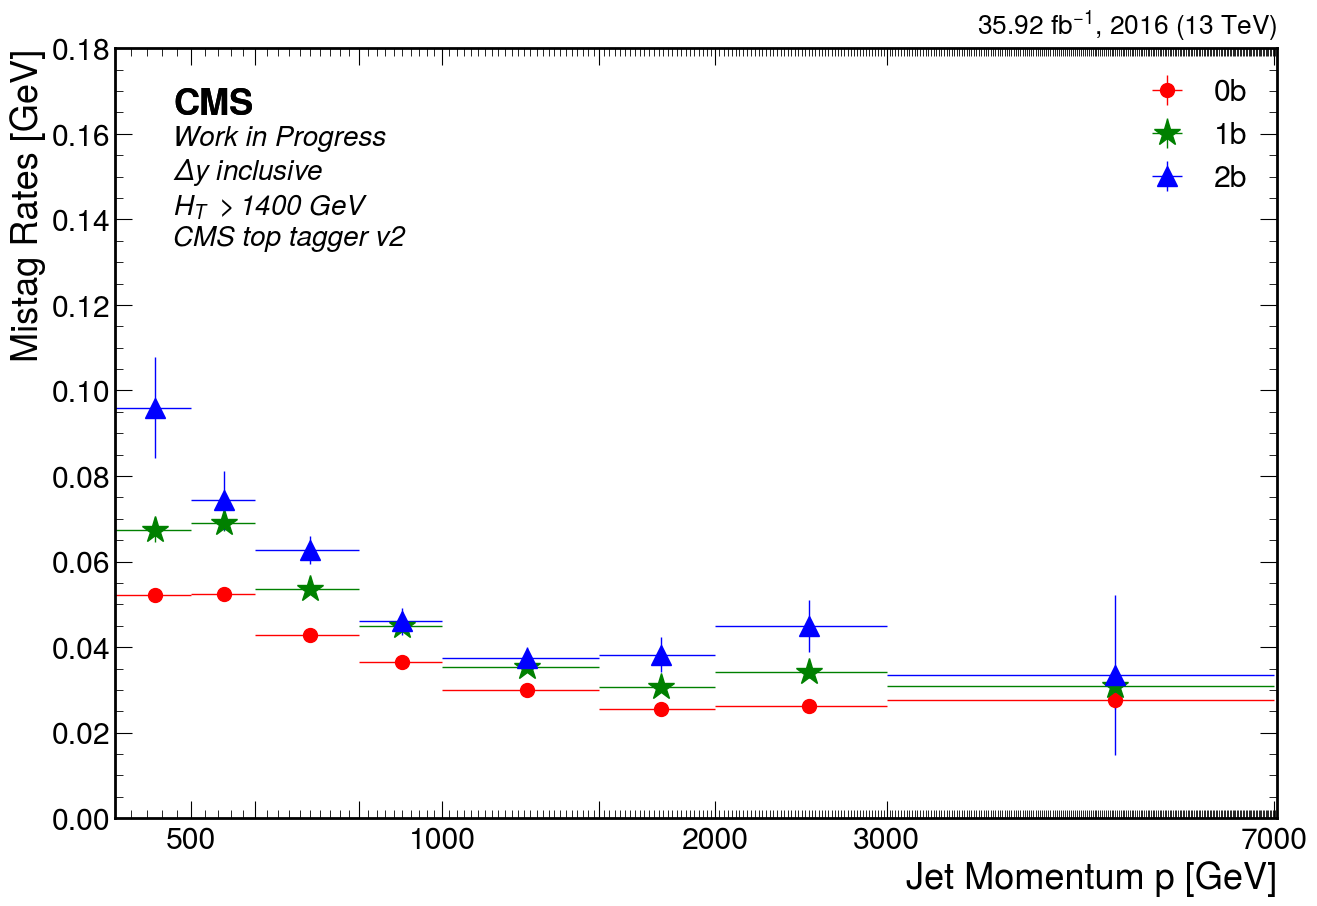

In [12]:
fig, ax = plt.subplots(
    figsize=(15,10),
    sharex=True
)

mistag0b = mistag['0b'].values
mistag1b = mistag['1b'].values
mistag2b = mistag['2b'].values

err0b = np.where(mistag['0berr'].values < 0, 0., mistag['0berr'].values)
err1b = np.where(mistag['1berr'].values < 0, 0., mistag['1berr'].values)
err2b = np.where(mistag['2berr'].values < 0, 0., mistag['2berr'].values)

bins = np.arange(len(mistag0b)+1)
pbins = np.array(mistag['jetp bins'].values)
pbins = np.append(pbins, 10000)

print(mistag0b)
print(pbins)

if Full2016:
    IOV = '2016all'

    hep.cms.label('', data=True, lumi=luminosity[IOV]/1000, year='2016', fontsize=20, loc=2)
    
btagger=''
if useOldTaggers: btagger='\nCSV b tagger v2'

hep.cms.text('Work in Progress'+'\n'
             +r'$\Delta y$ inclusive'+'\n'+r'$H_T\ > 1400\ GeV$'+'\n'
             +tagger+btagger,
             fontsize=20, loc=2)

plt.ylim(bottom = 0.0, top = 0.18)
# plt.ylim(bottom = 0.0, top = 0.26)
plt.xlim(400, 7050)

hep.histplot(mistag0b, pbins, ax=ax, xerr=True, yerr=err0b, histtype='errorbar', color='red', markersize=20)
hep.histplot(mistag1b, pbins, ax=ax, xerr=True, yerr=err1b, histtype='errorbar', color='green', marker='*', markersize=20)
hep.histplot(mistag2b, pbins, ax=ax, xerr=True, yerr=err2b, histtype='errorbar', color='blue', marker='^', markersize=15)

# ---- Optional x-axis scaling ---- #
ax.set_xscale('function', functions=(forward, inverse))
plt.xticks(np.array([400, 500, 600, 800, 1000, 1500, 2000, 3000, 7000]))
ax.set_xticklabels(['', 500, '', '', 1000, '', 2000, 3000, 7000])
ax.set_xlabel('Jet Momentum p [GeV]')
ax.set_ylabel('Mistag Rates [GeV]')
plt.legend(['0b', '1b', '2b'], loc='upper right')

# coffee = plt.text(1.0, 0.87, u"☕",
#               fontsize=50,
#               horizontalalignment='right',
#               verticalalignment='top',
#               transform=ax.transAxes
#              )

# QCDlabel = plt.text(0.85, 0.95, 'QCD Pythia 8',
#               weight='bold',
#               fontsize=20,
#               horizontalalignment='right',
#               verticalalignment='top',
#               transform=ax.transAxes
#              )

savefilename = f'../plots/images/pdf/mistagRate/'+IOV+'/mistag_'+tagger.lower().replace('top','').replace(' ','')+'.pdf'

# plt.savefig(savefilename)
# plt.savefig(savefilename.replace('pdf', 'png'))

print('saving', savefilename)
print('saving', savefilename.replace('pdf', 'png'))

plt.show()
